# Capstone 2
## Emporium Bookstore: Regional sales analysis under Len Jensen’s management between 2022 and 2025
### Analyst:
Sultan Simsek

## Territories Analyzed:
Charleston and Greenville/ South Carolina

## Project Goal
This project analyzes sales performance, customer activity, product categories,
and revenue trends for two EmporiUm sales territories in order to identify
marketing opportunities and business recommendations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ls


ProductCategories.csv          charts/
Products-2.csv                 customer_list.csv
README.md                      simsek_10_min_video_link.docx
StoreDetail.csv                simsek_store_analysis.ipynb
StoreSales.csv


In [4]:
stores_detail = pd.read_csv("StoreDetail.csv")
stores_detail.info()
stores_detail.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [5]:
stores_sales = pd.read_csv("StoreSales.csv")
stores_sales.info()
stores_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [6]:
prod_categories = pd.read_csv("ProductCategories.csv")
prod_categories.info()
prod_categories.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [7]:
prod = pd.read_csv("Products-2.csv")
prod.info()
prod.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:
customers = pd.read_csv(
    "customer_list.csv",
    sep='|'
)
customers.info()
customers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Data cleaning
### Missing Values
The dataset was checked for missing values using .isnull().sum(). 
RewardsID section was the only column with missing values, which showed the non-rewards memebr customers.
A small number of records contained missing customer IDs and revenue values.
They have been left as is since they didn't affect the sales calculations.

In [9]:
stores_detail.isnull().sum()

Store Location       0
State                0
Store ID             0
Territory Manager    0
Region               0
Region Director      0
dtype: int64

In [10]:
stores_sales.isnull().sum()

Transaction Date         0
Store ID                 0
RewardsID           300186
Prod Num                 0
Sale Amount              0
dtype: int64

In [11]:
prod_categories.isnull().sum()

CategoryID       0
Category         0
SubcategoryID    0
Subcategory      0
dtype: int64

In [12]:
prod.isnull().sum()

Prod Num         0
Product          0
CategoryID       0
SubcategoryID    0
dtype: int64

In [13]:
customers.isnull().sum()

cust_id         0
date            0
time            0
name            0
email           0
phone           1
sms-opt-out     1
dtype: int64

### Finding duplicates

In [14]:
stores_detail.duplicated().sum()

np.int64(0)

In [15]:
stores_sales.duplicated().sum()

np.int64(0)

In [16]:
prod.duplicated().sum()

np.int64(0)

In [17]:
prod_categories.duplicated().sum()

np.int64(0)

Dataset checked to see if there were duplicate transaction records which might affect the total revenue wrongly.

### Incorrect Datatypes

In [18]:
stores_sales['Transaction Date'] = pd.to_datetime(
    stores_sales['Transaction Date']
)

In [19]:
stores_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction Date  335129 non-null  datetime64[ns]
 1   Store ID          335129 non-null  int64         
 2   RewardsID         34943 non-null   float64       
 3   Prod Num          335129 non-null  object        
 4   Sale Amount       335129 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 12.8+ MB


In [20]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [21]:
customers['date'] = pd.to_datetime(
    customers['date']
)

In [22]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   cust_id       521 non-null    int64         
 1   date          521 non-null    datetime64[ns]
 2   time          521 non-null    object        
 3   name          521 non-null    object        
 4   email         521 non-null    object        
 5   phone         520 non-null    object        
 6   sms-opt-out   520 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 28.6+ KB


Several columns were reviewed for datatype accuracy.
The 'Transaction date' and 'date' columns were converted to datetime format to support
time-bound analysis.

### Importing Problems Fixed

In [23]:
customers = pd.read_csv(
    "customer_list.csv",
    sep='|',
    engine='python'
)

In [24]:
customers.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


Customers table was seperated with pipes, and looked like one object.
Modified it to be able reach each column seperately.

### Invalid Sales Amount?


In [25]:
stores_sales['Sale Amount'].describe()

count    335129.000000
mean        135.380850
std         279.716725
min           2.400000
25%          13.130000
50%          29.810000
75%         114.710000
max        1763.700000
Name: Sale Amount, dtype: float64

'Sale Amount' column is schecked to see if there are invalid amounts like negative(possible refunds), or left blank transactions, that might affect the total revenue. But didn't detect an unusual value.


In [26]:
stores_sales["Year"]  = stores_sales["Transaction Date"].dt.year
stores_sales["Month"] = stores_sales["Transaction Date"].dt.to_period("M")

## Core Project Requirements
**1.** Who are the territory managers for the sales territories assigned? What are the store IDs and cities
for the stores in each assigned sales territory?

In [27]:
# Filter for Len Jensen in South Carolina
len_stores = stores_detail[
    (stores_detail["Territory Manager"] == "Len Jensen")][["Store ID", "Store Location", "State", "Territory Manager"]]
 
print("Len Jensen's Stores")
print(len_stores.to_string(index=False))
# Expected: Charleston and Greenville stores with their IDs
 
# Get the list of Store IDs for all subsequent filtering
len_store_ids = len_stores["Store ID"].tolist()
 
# Split into two territories (each city = one territory for analysis)
charleston_ids  = len_stores[len_stores["Store Location"] == "Charleston"]["Store ID"].tolist()
greenville_ids  = len_stores[len_stores["Store Location"] == "Greenville"]["Store ID"].tolist()
 

Len Jensen's Stores
 Store ID Store Location          State Territory Manager
      852     Charleston South Carolina        Len Jensen
      853     Greenville South Carolina        Len Jensen


**2.** What is monthly total revenue for in-store sales in each of the two sales territories, over the full
period covered by the data?

In [28]:
# Only Len Jensen's stores
len_sales = stores_sales[stores_sales["Store ID"].isin(len_store_ids)].copy()
 
# Attach city name so we can split by territory
len_sales = len_sales.merge(
    stores_detail[["Store ID", "Store Location"]],
    on="Store ID", how="left"
)
 
# Monthly revenue per territory
monthly_rev = (
    len_sales
    .groupby(["Store Location", "Month"])["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Store Location": "Territory", "Sale Amount": "Monthly Revenue"})
)
 
print("Monthly Revenue by Territory (first 10 rows)")
print(monthly_rev.head(10).to_string(index=False))

Monthly Revenue by Territory (first 10 rows)
 Territory   Month  Monthly Revenue
Charleston 2022-01          7129.58
Charleston 2022-02          6473.06
Charleston 2022-03          3857.51
Charleston 2022-04          4887.79
Charleston 2022-05          2547.10
Charleston 2022-06          5193.38
Charleston 2022-07          6067.32
Charleston 2022-08          2534.36
Charleston 2022-09          3707.11
Charleston 2022-10          5678.24


**3.** How would you rank the sales performance of each store in each sales territory? Which are the
top-performing stores?

In [29]:
store_rev = (
    len_sales
    .groupby(["Store Location", "Store ID"])["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Total Revenue"})
    .sort_values("Total Revenue", ascending=False)
    .reset_index(drop=True)
)

store_rev.index += 1  # rank starts at 1
store_rev.index.name = "Rank"

print("Store Performance in Len Jensen's Territories")
print(store_rev.to_string())

Store Performance in Len Jensen's Territories
     Store Location  Store ID  Total Revenue
Rank                                        
1        Greenville       853      337002.00
2        Charleston       852      311810.56


**4.** Comparing the customer ID from the customer list data with the rewards ID from the sales data,
who were the top customers in each sales territory?

In [30]:
# Only transactions that have a RewardsID (loyalty members)
rewards_sales = len_sales.dropna(subset=["RewardsID"]).copy()
rewards_sales["RewardsID"] = rewards_sales["RewardsID"].astype(int)
 
# Sum spend per customer per territory
cust_spend = (
    rewards_sales
    .groupby(["Store Location", "RewardsID"])["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"RewardsID": "cust_id", "Sale Amount": "Total Spend"})
)
 
# Merge with customer names
top_customers = cust_spend.merge(
    customers[["cust_id", "name", "email"]],
    on="cust_id", how="left"
)
 
# Top 5 per territory
top_customers = (
    top_customers
    .sort_values("Total Spend", ascending=False)
    .groupby("Store Location")
    .head(5)
)
 
print("Top Customers by Territory")
print(top_customers[["Store Location","name","email","Total Spend"]]
      .to_string(index=False))

Top Customers by Territory
Store Location          name                    email  Total Spend
    Greenville      Jin Kwon    jin@dharma.initiative      1786.05
    Charleston     Roman Roy romulus@waystarroyco.com      1778.84
    Charleston          Jazz   jazz@banksresidence.la      1763.70
    Greenville     Ben Chang      chang@greendale.edu      1514.20
    Charleston  Debra Morgan     debra@miamimetro.gov      1388.56
    Greenville Dayanara Diaz      daya@litchfield.pen      1359.30
    Charleston     Pierce H.     pierce@greendale.edu      1317.70
    Greenville       Andy B.   andy@dundermifflin.com      1301.88
    Greenville      Cal Abar   cal@keenecounty.police      1294.30
    Charleston    AJ Soprano       aj@northjersey.net      1292.00


**5.** What is the number of transactions per month by product category in each assigned territory?
What is total sales revenue per month by category? What might this tell you about the most
popular products, and where could there be opportunity for growth?

In [31]:
# Build a product → category lookup
prod_lookup = prod.merge(
    prod_categories[["CategoryID","Category","SubcategoryID","Subcategory"]],
    on=["CategoryID","SubcategoryID"], how="left"
)[["Prod Num","Category","Subcategory"]]
 
# Attach category info to Len's sales
len_sales_cat = len_sales.merge(prod_lookup, on="Prod Num", how="left")
 
# Monthly transactions and revenue by territory + category
monthly_cat = (
    len_sales_cat
    .groupby(["Store Location","Month","Category"])
    .agg(Transactions=("Sale Amount","count"),
         Revenue=("Sale Amount","sum"))
    .reset_index()
)
 
print("Monthly Category Breakdown (first 12 rows)")
print(monthly_cat.head(12).to_string(index=False))
 
# Insight: which category drives the most overall revenue in Len's territory?
cat_summary = (
    monthly_cat
    .groupby(["Store Location","Category"])
    .agg(Total_Transactions=("Transactions","sum"),
         Total_Revenue=("Revenue","sum"))
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)
print("\nCategory Summary (all time, both territories):")
print(cat_summary.to_string(index=False))
 

Monthly Category Breakdown (first 12 rows)
Store Location   Month                 Category  Transactions  Revenue
    Charleston 2022-01  Apparel and Merchandise             7   165.90
    Charleston 2022-01             Art Supplies             2   136.33
    Charleston 2022-01          Books (General)             2    52.36
    Charleston 2022-01  Stationery and Supplies             3    26.57
    Charleston 2022-01 Technology & Accessories            10  6103.91
    Charleston 2022-01                Textbooks             4   644.51
    Charleston 2022-02  Apparel and Merchandise             4   195.44
    Charleston 2022-02             Art Supplies             5   129.32
    Charleston 2022-02          Books (General)             3    69.64
    Charleston 2022-02  Stationery and Supplies             7    77.62
    Charleston 2022-02 Technology & Accessories             7  5336.77
    Charleston 2022-02                Textbooks             4   726.93

Category Summary (all time, both 

**6.** What is your recommendation for where to focus marketing attention in the next quarter?

Marketing Recommendation
Based on the revenue and transaction data by category:
 
1. Identify the highest-revenue category, and push those with targeted promotions,
   loyalty points boosts, or bundle campaigns with less selling categories during peak months.
 
2. Identify the fastest-growing category Year Over Year, early investment in shelf space
   and digital ads can capture trend momentum.
 
3. The territory with lower per-store revenue should receive extra in-store
   event support (author signings, reading clubs etc.) to lift foot traffic.
 
4. The territory with lower per-store revenue, should get a store uplift in order to attract more
   people, such as areas to sit and enjoy while browsing books and a small cafe in-store to make them
   spend more time in the store and encourage them to spend in general.
 
6. Low-performing categories should be evaluated for
   reduced shelf space or placed closer to top sellers to increase visibility and accesibility..


**Bonus 7.** Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest.
Which transactions had a sale amount greater than $500?

In [32]:
jan_2024 = stores_sales[
    (stores_sales["Transaction Date"].dt.year  == 2024) &
    (stores_sales["Transaction Date"].dt.month == 1)
].sort_values("Sale Amount", ascending=False).copy()
 
print("Bonus: January 2024 – All Transactions (top 10 shown)")
print(jan_2024.head(10).to_string(index=False))
 
over_500 = jan_2024[jan_2024["Sale Amount"] > 500]
print(f"\nTransactions > $500 in Jan 2024: {len(over_500)}")
print(over_500[["Transaction Date","Store ID","Prod Num","Sale Amount"]]
      .to_string(index=False))

Bonus: January 2024 – All Transactions (top 10 shown)
Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount  Year   Month
      2024-01-09       872        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-09       731        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-31       822        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-27       736        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-27       701        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-18       736        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-10       823      337.0 105341-IT       1763.7  2024 2024-01
      2024-01-01       726        NaN 105341-IT       1763.7  2024 2024-01
      2024-01-03       724        NaN 105326-IT       1717.7  2024 2024-01
      2024-01-18       731      367.0 105326-IT       1717.7  2024 2024-01

Transactions > $500 in Jan 2024: 497
Transaction Date  Store ID  Prod Num  Sale Amount
      2024-01-09       872 105341

**Bonus 8.** Across the full dataset, what are the top/bottom 5 best-selling individual products by total revenue?

In [33]:
prod_rev = (
    stores_sales
    .groupby("Prod Num")["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Total Revenue"})
    .merge(prod[["Prod Num","Product"]], on="Prod Num", how="left")
    .sort_values("Total Revenue", ascending=False)
)
 
top5_prod    = prod_rev.head(5)
bottom5_prod = prod_rev.tail(5)
 
print("\nBonus: Top 5 Products by Revenue")
print(top5_prod[["Product","Total Revenue"]].to_string(index=False))
 
print("\nBonus: Bottom 5 Products by Revenue")
print(bottom5_prod[["Product","Total Revenue"]].to_string(index=False))
 


Bonus: Top 5 Products by Revenue
                        Product  Total Revenue
                MSI Creator Z16     1199316.00
Apple MacBook Pro (M2, 14-inch)     1082151.00
Apple MacBook Air (M2, 13-inch)     1003136.80
                 HP Pavilion 14      913919.76
              ASUS VivoBook S15      900524.00

Bonus: Bottom 5 Products by Revenue
                                    Product  Total Revenue
                    Your Money or Your Life         447.92
Magnetic Clips (Assorted Colors, Set of 12)         354.24
        DK Eyewitness Travel Guides: Europe         346.12
                                     Verity         305.40
 Sakura Pigma Micron Pens (Black, Set of 6)         221.76


**Bonus 9.** What is total revenue by region across the full dataset? Which region generates the most revenue? What's the rank of SC?

In [34]:
# Attach region info to all sales
all_sales_region = stores_sales.merge(
    stores_detail[["Store ID","Region","State"]],
    on="Store ID", how="left"
)
 
region_rev = (
    all_sales_region
    .groupby("Region")["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Total Revenue"})
    .sort_values("Total Revenue", ascending=False)
    .reset_index(drop=True)
)
region_rev["Rank"] = region_rev.index + 1
 
# Find SC's region and its rank
sc_region_name = stores_detail[stores_detail["State"] == "South Carolina"]["Region"].iloc[0]
sc_rank = region_rev[region_rev["Region"] == sc_region_name]["Rank"].iloc[0]
 
print("\nBonus: Revenue by Region")
print(region_rev.to_string(index=False))
print(f"\nSC belongs to the '{sc_region_name}' region — Rank #{sc_rank}")
 


Bonus: Revenue by Region
   Region  Total Revenue  Rank
Northeast    24237526.98     1
    South     7996850.12     2
     East     6723039.53     3
     West     6412632.22     4

SC belongs to the 'South' region — Rank #2


**Bonus 10.** Compare year-over-year revenue for your territories. Is each territory trending up or down between
years?

In [35]:
yoy = (
    len_sales
    .groupby(["Store Location","Year"])["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Annual Revenue"})
    .sort_values(["Store Location","Year"])
)
 
# Calculate YoY % change
yoy["YoY Change %"] = (
    yoy.groupby("Store Location")["Annual Revenue"]
    .pct_change() * 100
).round(2)
 
print("\nBonus: Year-over-Year Revenue (Len Jenson's Territories)")
print(yoy.to_string(index=False))
 
# Trend interpretation
for loc, grp in yoy.groupby("Store Location"):
    last_change = grp["YoY Change %"].dropna().iloc[-1] if len(grp) > 1 else None
    if last_change is not None:
        trend = "↑ UP" if last_change > 0 else "↓ DOWN"
        print(f"  {loc}: most recent YoY {trend} ({last_change:+.1f}%)")


Bonus: Year-over-Year Revenue (Len Jenson's Territories)
Store Location  Year  Annual Revenue  YoY Change %
    Charleston  2022        57870.01           NaN
    Charleston  2023        66943.42         15.68
    Charleston  2024        68111.62          1.75
    Charleston  2025       118885.51         74.55
    Greenville  2022        48625.30           NaN
    Greenville  2023        79319.34         63.12
    Greenville  2024        79414.85          0.12
    Greenville  2025       129642.51         63.25
  Charleston: most recent YoY ↑ UP (+74.5%)
  Greenville: most recent YoY ↑ UP (+63.2%)


## Charts

In [36]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "axes.facecolor":    "#f8f8f8",
    "figure.facecolor":  "white",
})
 
TEAL   = "#00B4D8"
ORANGE = "#e76f51"
GREEN  = "#2d6a4f"
RED    = "#c1121f"

### Top 5 vs Bottom 5 Individual Products by Total Revenue
Shows the products to invest in more and leave less shelf space.

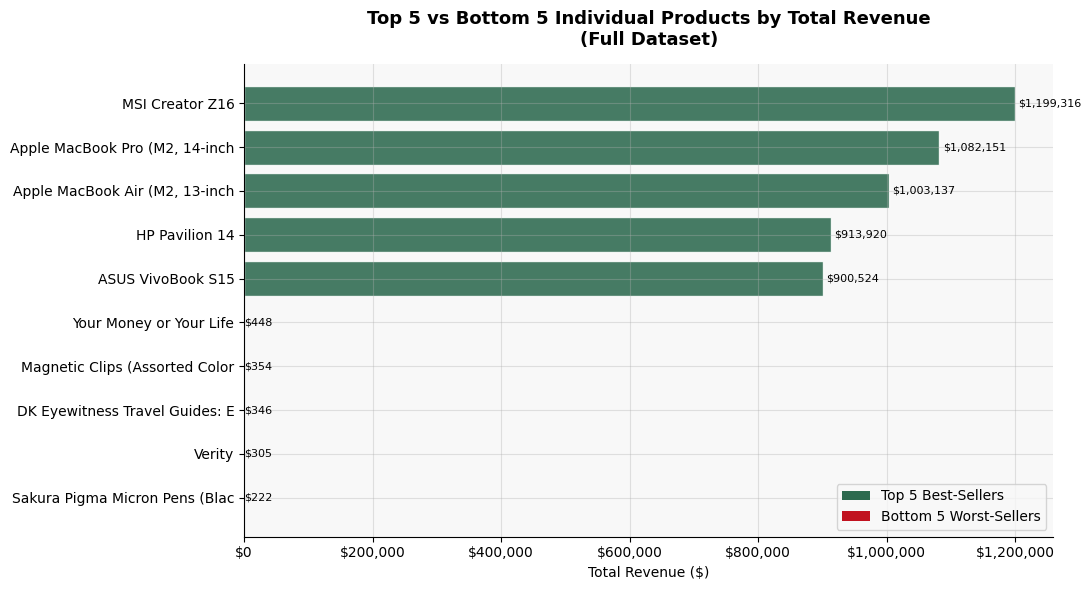

Chart 3 saved → chart3_top_bottom_products.png


In [37]:
combined = pd.concat([
    top5_prod.assign(Group="Top 5"),
    bottom5_prod.assign(Group="Bottom 5")
]).dropna(subset=["Product"])
 
# Shorten long product names for readability
combined["Short Name"] = combined["Product"].str[:30]
 
fig, ax = plt.subplots(figsize=(11, 6))
 
bar_colors = [GREEN] * 5 + [RED] * 5
bars = ax.barh(combined["Short Name"][::-1], combined["Total Revenue"][::-1],
               color=bar_colors[::-1], alpha=0.88, edgecolor="white")
 
for bar in bars:
    w = bar.get_width()
    ax.text(w + w * 0.005, bar.get_y() + bar.get_height() / 2,
            f"${w:,.0f}", va="center", fontsize=8)
 
# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=GREEN, label="Top 5 Best-Sellers"),
                   Patch(facecolor=RED,   label="Bottom 5 Worst-Sellers")]
ax.legend(handles=legend_elements, loc="lower right")
 
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_title("Top 5 vs Bottom 5 Individual Products by Total Revenue\n(Full Dataset)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig("chart3_top_bottom_products.png", dpi=150)
plt.show()
print("Chart 3 saved → chart3_top_bottom_products.png")
 

### Year-over-Year Revenue Trend
Shows the upward or downward movement of Total Revenue in each store.

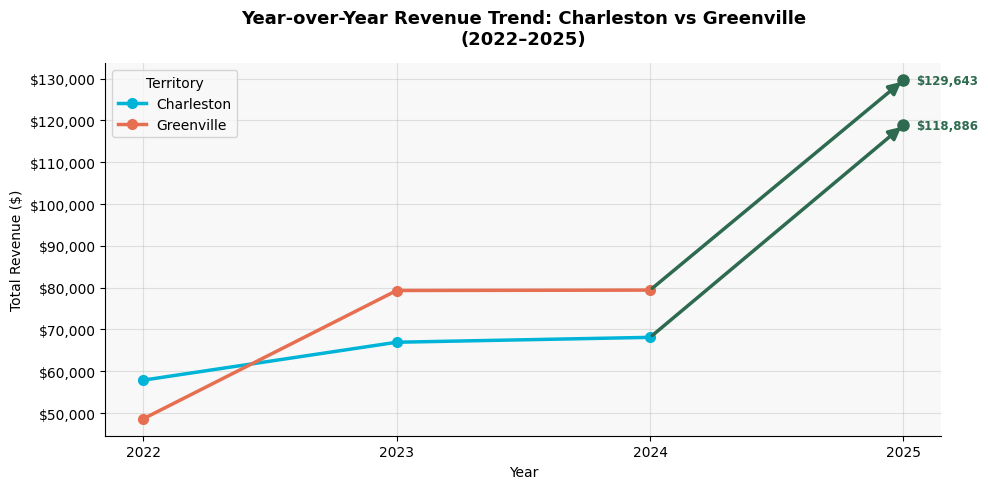

In [38]:
yoy_pivot = (
    len_sales
    .groupby(["Store Location", "Year"])["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Annual Revenue"})
    .pivot(index="Year", columns="Store Location", values="Annual Revenue")
    .fillna(0)
)

years = yoy_pivot.index.tolist()
locs  = yoy_pivot.columns.tolist()  # ['Charleston', 'Greenville']
line_colors = ["#00B4D8", "#e76f51"]  # cyan, orange — same as Chart 1

fig, ax = plt.subplots(figsize=(10, 5))

for loc, color in zip(locs, line_colors):
    values = yoy_pivot[loc].tolist()


    # Draw the main line (all segments except the last)
    ax.plot(years[:-1], values[:-1], color=color, linewidth=2.5,
            marker="o", markersize=7, label=loc, zorder=3)

    # Determine arrow tip color: green if last value > second-to-last, else red
    arrow_color = "#2d6a4f" if values[-1] >= values[-2] else "#c1121f"

    # Draw the final segment as an annotated arrow
    ax.annotate(
        "",
        xy=(years[-1], values[-1]),          # arrowhead (end point)
        xytext=(years[-2], values[-2]),       # arrow tail (start point)
        arrowprops=dict(
            arrowstyle="-|>",
            color=arrow_color,
            lw=2.5,
            mutation_scale=18                 # arrowhead size
        ),
        zorder=4
    )

    # Plot the final dot separately in arrow color
    ax.plot(years[-1], values[-1], "o", color=arrow_color,
            markersize=8, zorder=5)

    # Label the final value
    ax.text(years[-1] + 0.05, values[-1],
            f"${values[-1]:,.0f}", va="center", fontsize=8.5,
            color=arrow_color, fontweight="bold")

# Dollar formatting on y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))

# Clean x-axis — only show whole years
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years])


ax.set_title("Year-over-Year Revenue Trend: Charleston vs Greenville\n(2022–2025)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total Revenue ($)")
ax.legend(title="Territory")
plt.tight_layout()
plt.savefig("chart4_yoy_line.png", dpi=150)
plt.show()

**Extra Research** 


In [39]:
#Total Revenue
# prod_lookup
prod_lookup = prod.merge(
    prod_categories[["CategoryID","Category","SubcategoryID","Subcategory"]],
    on=["CategoryID","SubcategoryID"], how="left"
)[["Prod Num","Category","Subcategory"]]

len_sales_cat = len_sales.merge(prod_lookup, on="Prod Num", how="left")

# yoy table (from Bonus 10)
yoy = (
    len_sales
    .groupby(["Store Location","Year"])["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Annual Revenue"})
    .sort_values(["Store Location","Year"])
)
yoy["YoY Change %"] = (
    yoy.groupby("Store Location")["Annual Revenue"]
    .pct_change() * 100
).round(2)

# prod_rev (from Bonus 8)
prod_rev = (
    stores_sales
    .groupby("Prod Num")["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Total Revenue"})
    .merge(prod[["Prod Num","Product","CategoryID","SubcategoryID"]], on="Prod Num", how="left")
    .merge(prod_categories[["CategoryID","SubcategoryID","Category"]], on=["CategoryID","SubcategoryID"], how="left")
    .sort_values("Total Revenue", ascending=False)
)
top5_prod    = prod_rev.head(5)
bottom5_prod = prod_rev.tail(5)

In [41]:
import json

# ── 1. Total revenue both stores ────────────────────────────
total_rev = len_sales["Sale Amount"].sum()
print(f"grandTotal: {total_rev:,.2f}")

# ── 2a. Revenue per store ────────────────────────────────────
store_totals = (
    len_sales
    .groupby("Store Location")["Sale Amount"]
    .sum()
)
total_chs = store_totals.get("Charleston", 0)
total_grv = store_totals.get("Greenville", 0)
print(f"totalChs:   {total_chs:,.2f}")
print(f"totalGrv:   {total_grv:,.2f}")

# ── 2b. YoY % change per store (most recent year) ───────────
def last_yoy(city):
    grp = yoy[yoy["Store Location"] == city]["YoY Change %"].dropna()
    return grp.iloc[-1] if len(grp) else None

chs_yoy = last_yoy("Charleston")
grv_yoy = last_yoy("Greenville")
print(f"chsYoY:     {chs_yoy:+.1f}%")
print(f"grvYoY:     {grv_yoy:+.1f}%")

# combined YoY (total both stores, previous vs latest year)
latest_year = yoy["Year"].max()
prev_year   = latest_year - 1
rev_latest  = len_sales[len_sales["Year"] == latest_year]["Sale Amount"].sum()
rev_prev    = len_sales[len_sales["Year"] == prev_year]["Sale Amount"].sum()
total_yoy   = (rev_latest - rev_prev) / rev_prev * 100
print(f"totalYoY:   {total_yoy:+.1f}%")

# ── 2c. MoM % change per store (most recent 2 months) ───────
monthly_store = (
    len_sales
    .groupby(["Store Location","Month"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["Store Location","Month"])
)

def last_mom(city):
    grp = monthly_store[monthly_store["Store Location"] == city]["Sale Amount"]
    if len(grp) < 2:
        return None
    return (grp.iloc[-1] - grp.iloc[-2]) / grp.iloc[-2] * 100

chs_mom = last_mom("Charleston")
grv_mom = last_mom("Greenville")
print(f"chsMoM:     {chs_mom:+.1f}%")
print(f"grvMoM:     {grv_mom:+.1f}%")

# ── 3. Total transaction count ───────────────────────────────
txn_total = len(len_sales)
print(f"txnTotal:   {txn_total:,}")

# ── 4. YoY data for line chart (JS object format) ───────────
print("\n--- yoyData (paste into JS) ---")
yoy_dict = {}
for city, grp in yoy.groupby("Store Location"):
    yoy_dict[city] = {int(row["Year"]): round(row["Annual Revenue"], 2)
                      for _, row in grp.iterrows()}
print("const yoyData =", json.dumps(yoy_dict, indent=2))

# ── 5. Top 5 / Bottom 5 products (JS array format) ──────────
def prod_row(row, is_top):
    total_in_group = (
        top5_prod["Total Revenue"].sum() if is_top
        else bottom5_prod["Total Revenue"].sum()
    )
    return {
        "name": str(row["Product"]),
        "cat":  str(row["Category"]) if pd.notna(row.get("Category")) else "—",
        "rev":  round(row["Total Revenue"], 2),
        "top":  is_top
    }

prod_list = (
    [prod_row(r, True)  for _, r in top5_prod.iterrows()] +
    [prod_row(r, False) for _, r in bottom5_prod.iterrows()]
)
print("\n--- productData  ---")
print("const productData =", json.dumps(prod_list, indent=2))

# ── 6. Per capita ────────────────────────────────────────────
CHS_POP = 154000
GRV_POP = 72900
per_cap_chs = total_chs / CHS_POP
per_cap_grv = total_grv / GRV_POP
print(f"\nperCapChs:  ${per_cap_chs:.2f}")
print(f"perCapGrv:  ${per_cap_grv:.2f}")

# ── 7. Top 5 + Bottom 5 categories (JS array format) ────────
cat_total = (
    len_sales_cat
    .groupby("Category")["Sale Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sale Amount": "Total Revenue"})
    .sort_values("Total Revenue", ascending=False)
    .dropna(subset=["Category"])
)

top5_cat    = cat_total.head(5).copy()
bottom5_cat = cat_total.tail(5).copy()

top5_cat["top"]    = True
bottom5_cat["top"] = False
cats_combined = pd.concat([top5_cat, bottom5_cat])

cat_list = [
    {"name": row["Category"], "rev": round(row["Total Revenue"], 2), "top": row["top"]}
    for _, row in cats_combined.iterrows()
]
print("\n--- categoryData (paste into JS) ---")
print("const allCats =", json.dumps(cat_list, indent=2))

grandTotal: 648,812.56
totalChs:   311,810.56
totalGrv:   337,002.00
chsYoY:     +74.5%
grvYoY:     +63.2%
totalYoY:   +68.5%
chsMoM:     +38.0%
grvMoM:     +7.1%
txnTotal:   4,472

--- yoyData (paste into JS) ---
const yoyData = {
  "Charleston": {
    "2022": 57870.01,
    "2023": 66943.42,
    "2024": 68111.62,
    "2025": 118885.51
  },
  "Greenville": {
    "2022": 48625.3,
    "2023": 79319.34,
    "2024": 79414.85,
    "2025": 129642.51
  }
}

--- productData  ---
const productData = [
  {
    "name": "MSI Creator Z16",
    "cat": "Technology & Accessories",
    "rev": 1199316.0,
    "top": true
  },
  {
    "name": "Apple MacBook Pro (M2, 14-inch)",
    "cat": "Technology & Accessories",
    "rev": 1082151.0,
    "top": true
  },
  {
    "name": "Apple MacBook Air (M2, 13-inch)",
    "cat": "Technology & Accessories",
    "rev": 1003136.8,
    "top": true
  },
  {
    "name": "HP Pavilion 14",
    "cat": "Technology & Accessories",
    "rev": 913919.76,
    "top": true
  },
  {